# CNN Autoencoder

Third model. Same autoencoder idea as the MLP but using 1D conv layers instead of fully connected. The difference is conv layers slide a small filter across the 30 timesteps so they read local patterns in the signal — a sharp CO2 rise over 5 minutes, a sudden Light jump — things the MLP missed because it flattened everything into an unordered vector.

Architecture: encoder uses 1D convolutions to compress the sequence, decoder uses transposed convolutions to rebuild it. Reconstruction error is still the anomaly score.

## Load data

In [1]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

data = np.load('../data/prepared.npz')
X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_test  = data['y_test']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("test empty:", (y_test==0).sum(), "occupied:", (y_test==1).sum())

X_train: (2105, 30, 2)
X_test: (1551, 30, 2)
test empty: 452 occupied: 1099


## Normalize

Same as before, train stats only. But this time we don't flatten — CNN takes (batch, channels, timesteps) so we keep the sequence shape and just transpose.

In [2]:
train_mean = X_train.mean(axis=(0,1))
train_std  = X_train.std(axis=(0,1))

def norm(x): return (x - train_mean) / (train_std + 1e-8)

Xtr = norm(X_train)
Xva = norm(X_val)
Xte = norm(X_test)

# pytorch conv1d expects (batch, channels, length)
# our windows are (n, 30, 2) -> transpose to (n, 2, 30)
Xtr_t = torch.tensor(Xtr, dtype=torch.float32).permute(0, 2, 1)
Xva_t = torch.tensor(Xva, dtype=torch.float32).permute(0, 2, 1)
Xte_t = torch.tensor(Xte, dtype=torch.float32).permute(0, 2, 1)

print("train tensor:", Xtr_t.shape)   # (n, 2, 30)
print("test tensor:", Xte_t.shape)

train tensor: torch.Size([2105, 2, 30])
test tensor: torch.Size([1551, 2, 30])


## Define the CNN autoencoder

Encoder: two conv layers that compress the sequence. Decoder: two transposed conv layers that rebuild it. Kernel size 3 means each filter looks at 3 consecutive timesteps at a time.

In [3]:
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),                              # (8, 15)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8, 16, kernel_size=2, stride=2),  # (16, 30)
            nn.ReLU(),
            nn.Conv1d(16, 2, kernel_size=3, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = CNNAutoencoder()
print(model)

# quick shape check
with torch.no_grad():
    out = model(Xtr_t[:4])
    print("input:", Xtr_t[:4].shape, "-> output:", out.shape)

CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(2, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(8, 16, kernel_size=(2,), stride=(2,))
    (1): ReLU()
    (2): Conv1d(16, 2, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)
input: torch.Size([4, 2, 30]) -> output: torch.Size([4, 2, 30])


## Train

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    out = model(Xtr_t)
    loss = loss_fn(out, Xtr_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t), Xva_t)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  train {loss.item():.4f}  val {val_loss.item():.4f}")

epoch  10  train 0.9772  val 1.3214


epoch  20  train 0.9346  val 1.2453


epoch  30  train 0.8516  val 1.0873


epoch  40  train 0.7142  val 0.8238


epoch  50  train 0.5213  val 0.4772


epoch  60  train 0.3353  val 0.2304


epoch  70  train 0.1995  val 0.1326


epoch  80  train 0.1030  val 0.0941


epoch  90  train 0.0659  val 0.0864


epoch 100  train 0.0414  val 0.0515


## Loss curves

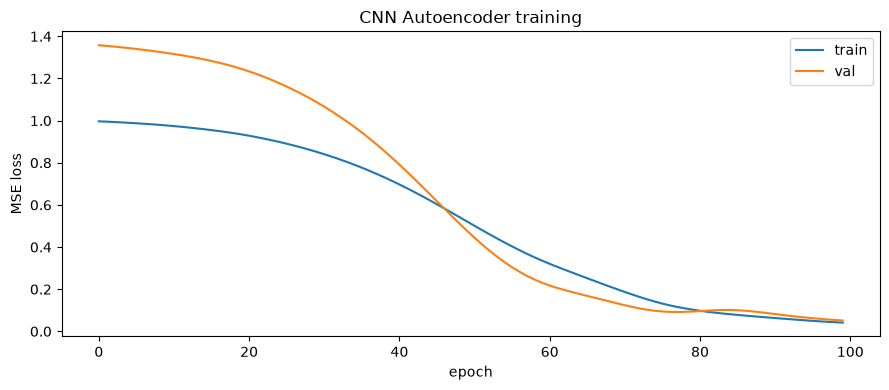

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('CNN Autoencoder training')
plt.legend(); plt.tight_layout()
plt.savefig('../results/04_cnn_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly score

Per-window reconstruction error. Mean squared diff across all channels and timesteps for each window.

In [6]:
model.eval()
with torch.no_grad():
    val_recon  = model(Xva_t)
    test_recon = model(Xte_t)

val_scores  = ((Xva_t - val_recon)**2).mean(dim=(1,2)).numpy()
test_scores = ((Xte_t - test_recon)**2).mean(dim=(1,2)).numpy()

print("val score range:", val_scores.min(), "to", val_scores.max())
print("test score range:", test_scores.min(), "to", test_scores.max())

val score range: 0.001937905 to 0.2927604
test score range: 0.006626371 to 3.1016643


## Threshold

In [7]:
threshold = np.percentile(val_scores, 95)
print("threshold:", threshold)

y_pred = (test_scores > threshold).astype(int)
print("predicted occupied:", y_pred.sum(), "out of", len(y_pred))

threshold: 0.16705132
predicted occupied: 1265 out of 1551


## Evaluate

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, test_scores)

print("precision:", round(prec,3))
print("recall:   ", round(rec,3))
print("f1:       ", round(f1,3))
print("roc-auc:  ", round(auc,3))
print("\nconfusion matrix:")
print(confusion_matrix(y_test, y_pred))

precision: 0.858
recall:    0.988
f1:        0.919
roc-auc:   0.707

confusion matrix:
[[ 273  179]
 [  13 1086]]


## Score distribution

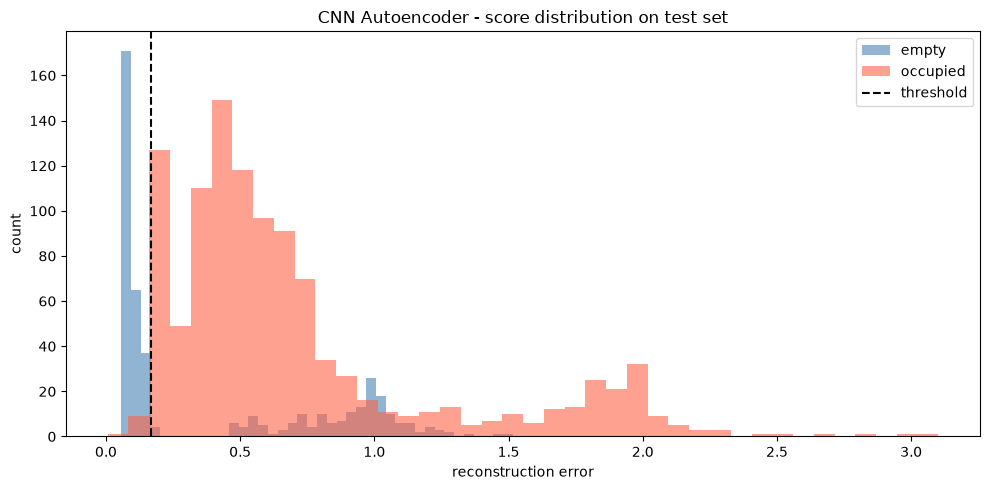

In [9]:
plt.figure(figsize=(10,5))
plt.hist(test_scores[y_test==0], bins=40, alpha=0.6, label='empty', color='steelblue')
plt.hist(test_scores[y_test==1], bins=40, alpha=0.6, label='occupied', color='tomato')
plt.axvline(threshold, color='black', linestyle='--', label='threshold')
plt.xlabel('reconstruction error'); plt.ylabel('count')
plt.title('CNN Autoencoder - score distribution on test set')
plt.legend(); plt.tight_layout()
plt.savefig('../results/04_cnn_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Save scores

In [10]:
np.savez('../results/cnn_scores.npz', test_scores=test_scores, y_test=y_test)
print("saved")

saved
